This notebook trains the existing models on the data, where COVID recession is included, and produces forecast values

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os 
os.environ['KERAS_BACKEND'] = 'torch'
import keras
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from models_code.ffnn import ffnn
from models_code.rnn import rnn
from models_code.arimax import arimax
from models_code.naive_forecast import naive_forecast

In [2]:
cpi = pd.read_csv('..\\data\\recession_test_data\\structured_data_recession\\CPI_growth_yoy_dataframe.csv')
rgdp = pd.read_csv('..\\data\\recession_test_data\\structured_data_recession\\RGDP_growth_dataframe.csv')
unemp = pd.read_csv('..\\data\\recession_test_data\\structured_data_recession\\unemployment_rate_dataframe.csv')
# dropping the unwanted duplicate columns and indexes, renaming the observed value columns
cpi = cpi.drop(['Unnamed: 0'], axis = 1).rename(columns = {'OBS_VALUE': 'CPI inflation'})
rgdp = rgdp.drop(['Unnamed: 0', 'Reference area', 'TIME_PERIOD'], axis = 1).rename(columns = {'OBS_VALUE': 'RGDP growth'})
unemp = unemp.drop(['Unnamed: 0', 'Reference area', 'TIME_PERIOD'], axis = 1).rename(columns = {'OBS_VALUE': 'Unemp rate'})
# concatenating along the columns
df = pd.concat((cpi, rgdp, unemp), axis = 1)

In [5]:
result_naive = naive_forecast(df, test_years = [2020, 2023])
result_naive.to_csv('..\\data\\recession_test_data\\recession_forecasts\\naive_forecasts_recession_dataframe.csv')

In [ ]:
model_ffnn = ffnn(df, column_names_to_difference = ['CPI inflation', 'Unemp rate'], train_years = [1994, 2017], 
            val_years = [2018, 2019], test_years = [2020, 2023])
result_ffnn = model_ffnn.rolling_origin_forecast()
result_ffnn.to_csv('..\\data\\recession_test_data\\recession_forecasts\\FFNN_forecasts_recession_dataframe.csv')

starting rolling-origin forecast...
end of rolling-origin forecast...


In [ ]:
model_rnn = rnn(df, column_names_to_difference = ['CPI inflation', 'Unemp rate'], train_years = [1994, 2017], 
            val_years = [2018, 2019], test_years = [2020, 2023])
result_rnn = model_rnn.rolling_origin_forecast()
result_rnn.to_csv('..\\data\\recession_test_data\\recession_forecasts\\RNN_forecasts_recession_dataframe.csv')

starting rolling-origin forecast...


c:\python projects\Economics_forecasting\.venv\Lib\site-packages\keras\src\backend\torch\rnn.py:887: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  outputs, h_n = torch._VF.gru(


end of rolling-origin forecast...


In [ ]:
model_arimax = arimax(df, ['CPI inflation'], [1994, 2017], [2018, 2019], [2020, 2023])
result_arimax = model_arimax.rolling_origin_forecasting()
result_arimax.to_csv('..\\data\\recession_test_data\\recession_forecasts\\ARIMAX_forecasts_recession_dataframe.csv')

starting rolling-origin forecast...
Mexico step 3: fit did not converge, order=[1, 0, 0]


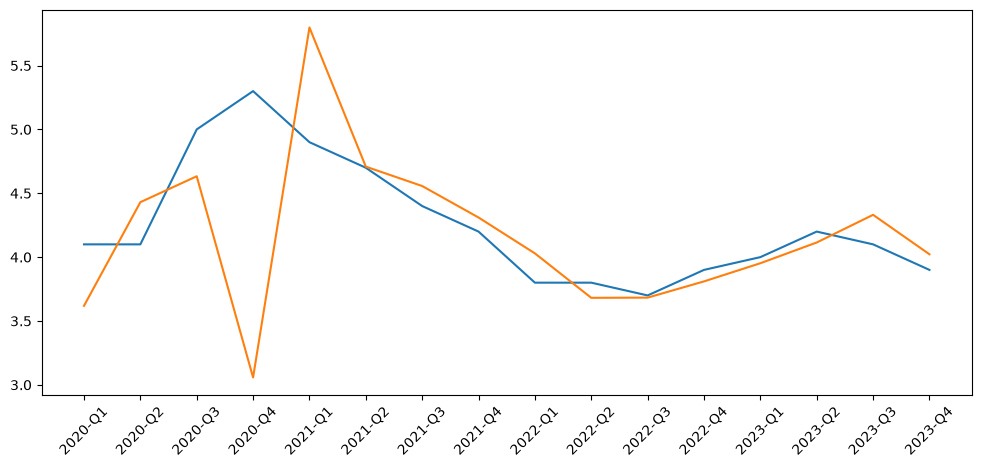

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))

us_data = result_arimax[result_arimax['Reference area'] == 'United Kingdom']

ax.plot(us_data['TIME_PERIOD'], us_data['Unemp rate'])
ax.plot(us_data['TIME_PERIOD'], us_data['Forecasts'])
plt.xticks(rotation=45)
plt.show()